**Impor Library**

In [218]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

**Load and Read Dataset**

In [219]:
# Ganti URL di bawah ini dengan link 'Raw' dari file CSV di GitHub Anda
url = 'https://raw.githubusercontent.com/IzzahHuwaidah/sumatra-rice-prediction/refs/heads/main/Data_Tanaman_Padi_Sumatera_version_1.csv'

# Load dan read dataset langsung dari internet
df = pd.read_csv(url)

# Menampilkan 5 baris pertama untuk memastikan data berhasil dimuat
display(df.head())

,Provinsi,Tahun,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata
0,Aceh,1993,1329536.0,323589.0,1627.0,82.00,26.06
1,Aceh,1994,1299699.0,329041.0,1521.0,82.12,26.92
2,Aceh,1995,1382905.0,339253.0,1476.0,82.72,26.27
3,Aceh,1996,1419128.0,348223.0,1557.0,83.00,26.08
4,Aceh,1997,1368074.0,337561.0,1339.0,82.46,26.31


In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Provinsi        224 non-null    object 
 1   Tahun           224 non-null    int64  
 2   Produksi        224 non-null    float64
 3   Luas Panen      224 non-null    float64
 4   Curah hujan     224 non-null    float64
 5   Kelembapan      224 non-null    float64
 6   Suhu rata-rata  224 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 12.4+ KB


In [221]:
# Statistik deskriptif
print("\nStatistik Deskriptif:")
print(df.describe())


Statistik Deskriptif:
             Tahun      Produksi     Luas Panen  Curah hujan  Kelembapan  \
count   224.000000  2.240000e+02     224.000000   224.000000  224.000000   
mean   2006.500000  1.679701e+06  374349.966920  2452.490759   80.948705   
std       8.095838  1.161387e+06  232751.161987  1031.972625    4.878680   
min    1993.000000  4.293800e+04   63142.040000   222.500000   54.200000   
25%    1999.750000  5.488570e+05  146919.500000  1703.525000   78.975000   
50%    2006.500000  1.667773e+06  373551.500000  2315.700000   82.375000   
75%    2013.250000  2.436851e+06  514570.250000  3039.700000   84.000000   
max    2020.000000  4.881089e+06  872737.000000  5522.000000   90.600000   

       Suhu rata-rata  
count      224.000000  
mean        26.801964  
std          1.197041  
min         22.190000  
25%         26.177500  
50%         26.730000  
75%         27.200000  
max         29.850000  


In [222]:
# Missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Provinsi          0
Tahun             0
Produksi          0
Luas Panen        0
Curah hujan       0
Kelembapan        0
Suhu rata-rata    0
dtype: int64


In [223]:
# Data duplikat
print("\nJumlah Data Duplikat:", df.duplicated().sum())


Jumlah Data Duplikat: 0


## **EDA(Exploratory Data Analysis)**

### 1. Rata-rata Produksi Padi per Provinsi (1993-2020)

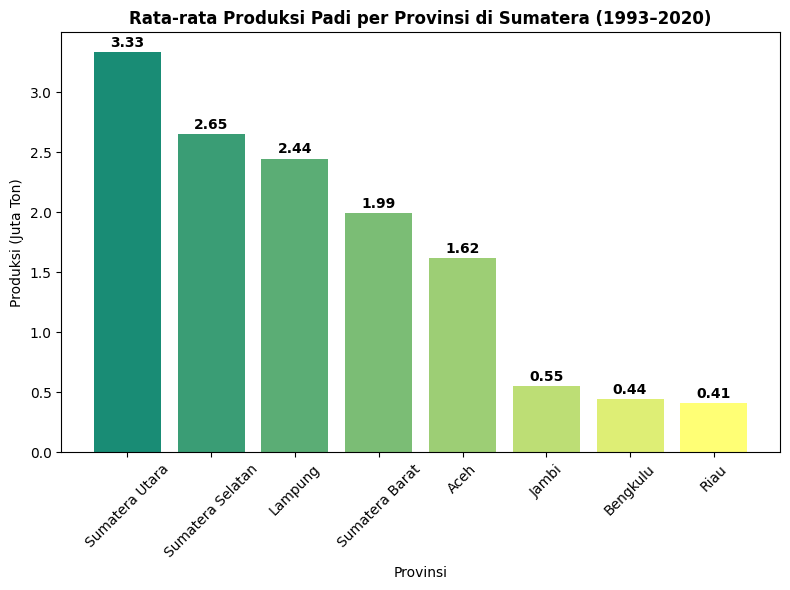

In [224]:
# Rata-rata produksi padi per provinsi dan diurutkan dari yang tertinggi
avg_prov = (
    df.groupby('Provinsi')['Produksi']
    .mean()
    .sort_values(ascending=False) / 1e6)

plt.figure(figsize=(8, 6))

bars = plt.bar(
    avg_prov.index,
    avg_prov.values,
    color=plt.cm.summer(np.linspace(0, 1, len(avg_prov))),
    alpha=0.9)

plt.title('Rata-rata Produksi Padi per Provinsi di Sumatera (1993–2020)', fontweight='bold')
plt.xlabel('Provinsi')
plt.ylabel('Produksi (Juta Ton)')

plt.xticks(rotation=45)

# Label angka di atas bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f'{bar.get_height():.2f}',
        ha='center',
        va='bottom',
        fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

Dari visualisasi rata-rata produksi padi per provinsi, terlihat bahwa:
*   **Sumatera Utara** memiliki rata-rata produksi padi tertinggi.
*   **Sumatera Selatan** dan **Lampung** menyusul dengan rata-rata produksi yang signifikan.
*   Provinsi seperti **Riau**, **Bengkulu**, dan **Jambi** memiliki rata-rata produksi yang lebih rendah dibandingkan provinsi lainnya di Sumatera.

### 2. Tren Produksi Padi di Sumatera (1993-2020)

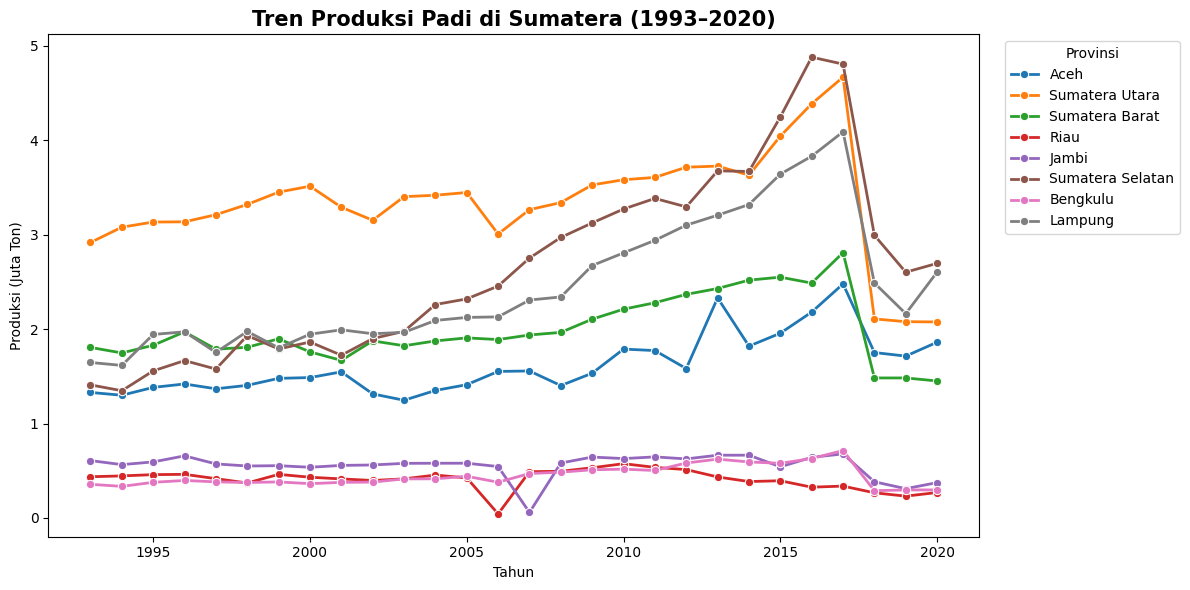

In [225]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="Tahun",
    y=df["Produksi"] / 1e6,
    hue="Provinsi",
    marker="o",
    linewidth=2,
    palette="tab10"
)

plt.title("Tren Produksi Padi di Sumatera (1993–2020)", fontsize=15,fontweight='bold')
plt.xlabel("Tahun")
plt.ylabel("Produksi (Juta Ton)")

plt.legend(
    title="Provinsi",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

Visualisasi tren menunjukkan:
*   Secara keseluruhan, ada **peningkatan tren produksi padi** di Sumatera dari tahun 1993 hingga 2020.
*   Produksi Padi tertinggi di hampir semua provinsi terjadi pada tahun 2017

### 3. Korelasi Antar Kolom Data

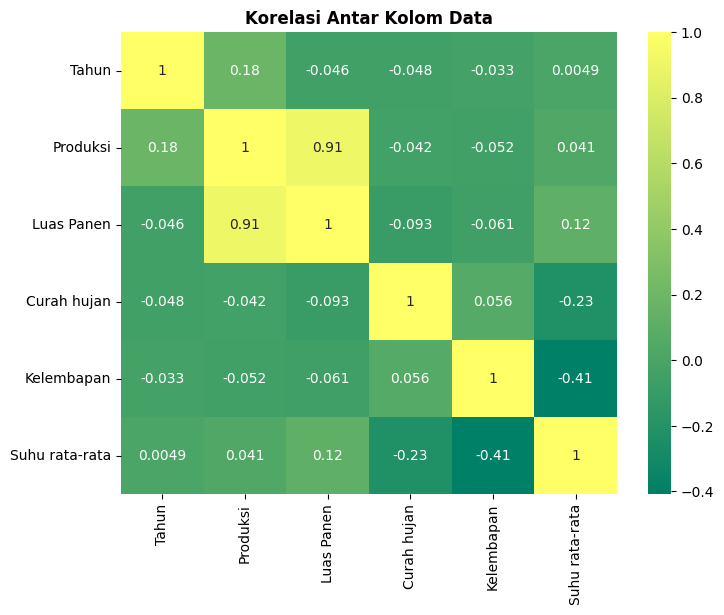

In [226]:
# Visualisasi matriks korelasi antar kolom data
corr_mat = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_mat, cmap = 'summer', annot = True)
plt.title('Korelasi Antar Kolom Data',fontweight='bold')
plt.show()

Dari heatmap korelasi:
*   Terdapat **korelasi positif yang sangat kuat antara 'Produksi' dan 'Luas Panen' (0.91)**, menunjukkan bahwa peningkatan luas panen sangat berkorelasi dengan peningkatan produksi padi.
*   Korelasi antara variabel lain seperti 'Curah hujan', 'Kelembapan', dan 'Suhu rata-rata' dengan 'Produksi' relatif rendah atau negatif, menunjukkan bahwa faktor-faktor ini mungkin memiliki pengaruh tidak langsung terhadap produksi dibandingkan luas panen.

### 4. Hubungan Luas Panen dan Produksi Padi

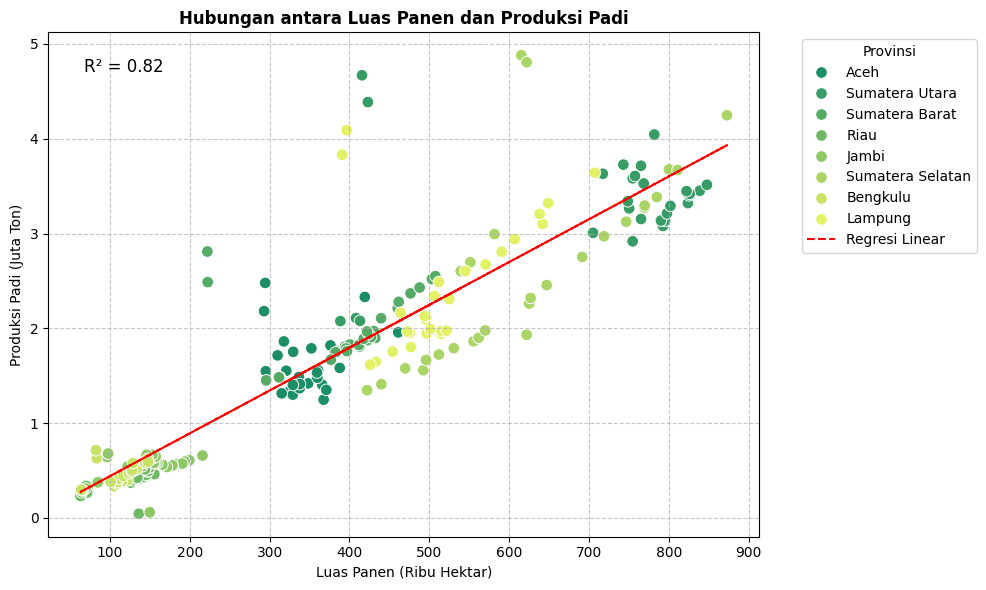

In [227]:
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(data=df, x=df['Luas Panen']/1e3, y=df['Produksi']/1e6, hue='Provinsi', palette='summer', s=70)

# Calculate linear regression
x_data = df['Luas Panen'] / 1e3
y_data = df['Produksi'] / 1e6
m, b = np.polyfit(x_data, y_data, 1)

# Plot the regression line
plt.plot(x_data, m*x_data + b, color='red', linestyle='--', label=f'Regresi Linear')

# Calculate R-squared
r = np.corrcoef(x_data, y_data)[0, 1]
plt.text(0.05, 0.95, f'R² = {r**2:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top')

plt.title('Hubungan antara Luas Panen dan Produksi Padi', fontweight='bold')
plt.xlabel('Luas Panen (Ribu Hektar)')
plt.ylabel('Produksi Padi (Juta Ton)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Provinsi', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Dari scatter plot hubungan antara Luas Panen dan Produksi Padi:
*   Terlihat **hubungan linear positif** yang kuat antara luas panen dan produksi, mengkonfirmasi korelasi tinggi yang ditemukan di heatmap.
*   Semakin besar luas panen, cenderung semakin tinggi pula produksi padi.

## **Data Preprocessing (Feature Engineering)**

CEK OUTLIER

<Axes: xlabel='Produksi'>

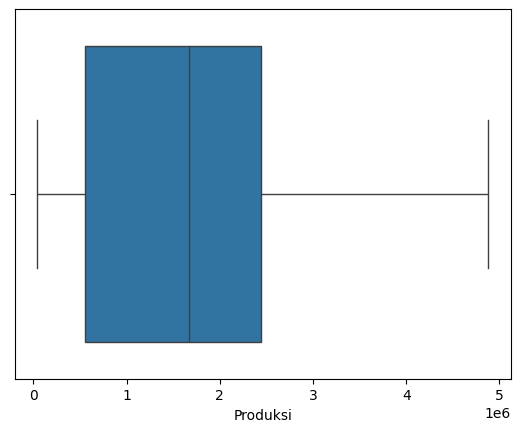

In [228]:
sns.boxplot(x=df['Produksi'])

Tidak terlihat adanya outlier ekstrem pada data Produksi. Artinya distribusi produksi padi masih cukup normal/stabil,
tidak ada nilai yang terlalu jauh menyimpang dari data lainnya.

FEATURE ENCODING

In [229]:
# Mengubah kolom kategorikal 'Provinsi'
# menjadi bentuk numerik menggunakan One Hot Encoding

encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(df[['Provinsi']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Provinsi'])
)

# Gabungkan hasil encoding ke dataframe utama
df = pd.concat([df, encoded_df], axis=1)

# Hapus kolom asli
df.drop(columns='Provinsi', inplace=True)

print("\nDataset setelah Encoding:")
display(df.head())



Dataset setelah Encoding:


,Tahun,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata,Provinsi_Aceh,Provinsi_Bengkulu,Provinsi_Jambi,Provinsi_Lampung,Provinsi_Riau,Provinsi_Sumatera Barat,Provinsi_Sumatera Selatan,Provinsi_Sumatera Utara
0,1993,1329536.0,323589.0,1627.0,82.00,26.06,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1994,1299699.0,329041.0,1521.0,82.12,26.92,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1995,1382905.0,339253.0,1476.0,82.72,26.27,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1996,1419128.0,348223.0,1557.0,83.00,26.08,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1997,1368074.0,337561.0,1339.0,82.46,26.31,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


FEATURE SELECTION

In [230]:
df = df.drop(columns='Tahun')

print("\nKolom setelah Feature Selection:")
print(df.columns)
display(df.head())



Kolom setelah Feature Selection:
Index(['Produksi', 'Luas Panen', 'Curah hujan', 'Kelembapan', 'Suhu rata-rata',
       'Provinsi_Aceh', 'Provinsi_Bengkulu', 'Provinsi_Jambi',
       'Provinsi_Lampung', 'Provinsi_Riau', 'Provinsi_Sumatera Barat',
       'Provinsi_Sumatera Selatan', 'Provinsi_Sumatera Utara'],
      dtype='object')


,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata,Provinsi_Aceh,Provinsi_Bengkulu,Provinsi_Jambi,Provinsi_Lampung,Provinsi_Riau,Provinsi_Sumatera Barat,Provinsi_Sumatera Selatan,Provinsi_Sumatera Utara
0,1329536.0,323589.0,1627.0,82.00,26.06,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1299699.0,329041.0,1521.0,82.12,26.92,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1382905.0,339253.0,1476.0,82.72,26.27,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1419128.0,348223.0,1557.0,83.00,26.08,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1368074.0,337561.0,1339.0,82.46,26.31,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


MEMISAHKAN FITUR DAN TARGET

In [231]:
X = df.drop(columns='Produksi')
y = df[['Produksi']]

print("\nShape Feature:")
print(X.shape)

print("\nShape Target:")
print(y.shape)


Shape Feature:
(224, 12)

Shape Target:
(224, 1)


TRAIN TEST SPLIT

In [232]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("\nX_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)


X_train : (156, 12)
X_test  : (68, 12)
y_train : (156, 1)
y_test  : (68, 1)


FEATURE SCALING

In [233]:
numeric_cols = [
    'Luas Panen',
    'Curah hujan',
    'Kelembapan',
    'Suhu rata-rata'
]

# =========================================================
# STANDARDIZATION
# =========================================================

scaler = StandardScaler()

# copy dataset agar data asli aman
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# scaling hanya fitur numerik
X_train_scaled[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

# gunakan transform, bukan fit_transform
X_test_scaled[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

# =========================================================
# HASIL SCALING
# =========================================================

print("\nData X_train setelah Scaling:")
display(X_train_scaled.head())

print("\nData X_test setelah Scaling:")
display(X_test_scaled.head())


Data X_train setelah Scaling:


,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata,Provinsi_Aceh,Provinsi_Bengkulu,Provinsi_Jambi,Provinsi_Lampung,Provinsi_Riau,Provinsi_Sumatera Barat,Provinsi_Sumatera Selatan,Provinsi_Sumatera Utara
109,-1.314266,-0.591643,-2.038426,-1.545051,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
136,-1.205392,-0.234001,0.538980,-0.170947,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
108,-1.320207,0.559121,0.760137,-0.103090,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
65,0.149474,1.822872,-2.026025,1.160745,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,-0.870923,0.003122,0.448037,-0.408447,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0



Data X_test setelah Scaling:


,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata,Provinsi_Aceh,Provinsi_Bengkulu,Provinsi_Jambi,Provinsi_Lampung,Provinsi_Riau,Provinsi_Sumatera Barat,Provinsi_Sumatera Selatan,Provinsi_Sumatera Utara
9,-0.303258,-1.134284,-2.548947,2.017439,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
84,-1.004408,0.313561,1.092905,-0.696839,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,-0.869018,-0.042575,0.493509,-0.035233,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
144,0.337903,-0.871651,-0.539934,-0.060680,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
221,0.513280,-1.044899,-1.040120,-1.120945,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [234]:
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train)

y_test_scaled = y_scaler.transform(y_test)

# Ubah menjadi DataFrame agar lebih rapi
y_train_scaled = pd.DataFrame(
    y_train_scaled,
    columns=['Produksi_scaled']
)

y_test_scaled = pd.DataFrame(
    y_test_scaled,
    columns=['Produksi_scaled']
)

# Tampilkan hasil
print("Data y_train setelah scaling:")
display(y_train_scaled.head())

print("Data y_test setelah scaling:")
display(y_test_scaled.head())

Data y_train setelah scaling:


,Produksi_scaled
0,-1.247470
1,-0.904438
2,-1.188282
3,0.093377
4,-1.008148


Data y_test setelah scaling:


,Produksi_scaled
0,-0.374552
1,-1.105908
2,-1.010951
3,-0.155252
4,0.603910


In [235]:
print("\n=== FINAL DATASET ===")

print("Training Feature :", X_train_scaled.shape)
print("Testing Feature  :", X_test_scaled.shape)

print("Training Target  :", y_train_scaled.shape)
print("Testing Target   :", y_test_scaled.shape)


print("\n=== CHECK MISSING VALUE ===")

print("Missing value X_train :", X_train_scaled.isnull().sum().sum())
print("Missing value X_test  :", X_test_scaled.isnull().sum().sum())

print("Missing value y_train :", y_train_scaled.isnull().sum().sum())
print("Missing value y_test  :", y_test_scaled.isnull().sum().sum())


=== FINAL DATASET ===
Training Feature : (156, 12)
Testing Feature  : (68, 12)
Training Target  : (156, 1)
Testing Target   : (68, 1)

=== CHECK MISSING VALUE ===
Missing value X_train : 0
Missing value X_test  : 0
Missing value y_train : 0
Missing value y_test  : 0


In [236]:
display(X_train_scaled[numeric_cols].describe().round(2))
display(y_train_scaled.describe().round(2))

,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata
count,156.00,156.00,156.00,156.00
mean,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00
min,-1.35,-2.21,-5.56,-3.93
25%,-1.00,-0.65,-0.33,-0.48
50%,-0.01,-0.12,0.27,-0.02
75%,0.66,0.57,0.62,0.32
max,2.01,3.11,1.97,2.44


,Produksi_scaled
count,156.00
mean,-0.00
std,1.00
min,-1.42
25%,-1.00
50%,-0.01
75%,0.70
max,2.60


kalo ak ada salah brkabar soalnya ada yg beda sama kagglenya ( yang test ga pake fit.tr

##**Linear Regression**

Evaluasi Linear Regression

In [237]:
# model Linear Regression
linreg = LinearRegression()

# Training model menggunakan data yang sudah discaling
linreg.fit(X_train_scaled, y_train_scaled.values.ravel())

# Prediksi dalam bentuk scaled
y_train_pred_scaled = linreg.predict(X_train_scaled)
y_test_pred_scaled = linreg.predict(X_test_scaled)

# Inverse transform agar kembali ke satuan asli Produksi
y_train_actual = y_scaler.inverse_transform(y_train_scaled)
y_test_actual = y_scaler.inverse_transform(y_test_scaled)

y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1))
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1))

# Ubah hasil prediksi ke DataFrame
pred_linreg = pd.DataFrame({
    "Actual Produksi": y_test_actual.ravel(),
    "Predicted Produksi": y_test_pred.ravel()
})

display(pred_linreg.head())
display(pred_linreg.tail())

,Actual Produksi,Predicted Produksi
0,1314165.00,1.461202e+06
1,436297.00,5.188474e+05
2,550277.00,6.696411e+05
3,1577398.00,2.292944e+06
4,2488641.91,2.460298e+06


,Actual Produksi,Predicted Produksi
63,2940795.0,2.647427e+06
64,657650.0,7.703765e+05
65,2129914.0,2.342295e+06
66,1404580.0,1.663717e+06
67,1806424.0,2.088771e+06


Evaluasi Model Linear Regression

In [238]:
# Evaluasi Model
def evaluate_regression_model(model_name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    train_r2 = r2_score(y_train_true, y_train_pred)
    test_r2 = r2_score(y_test_true, y_test_pred)

    train_mae = mean_absolute_error(y_train_true, y_train_pred)
    test_mae = mean_absolute_error(y_test_true, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))

    train_mape = mean_absolute_percentage_error(y_train_true, y_train_pred) * 100
    test_mape = mean_absolute_percentage_error(y_test_true, y_test_pred) * 100

    result = pd.DataFrame({
        "Model": [model_name],
        "Train R2": [train_r2],
        "Test R2": [test_r2],
        "Train MAE": [train_mae],
        "Test MAE": [test_mae],
        "Train RMSE": [train_rmse],
        "Test RMSE": [test_rmse],
        "Train MAPE (%)": [train_mape],
        "Test MAPE (%)": [test_mape]
    })

    return result


baseline_result = evaluate_regression_model(
    "Linear Regression Baseline",
    y_train_actual,
    y_train_pred,
    y_test_actual,
    y_test_pred
)

display(baseline_result)

,Model,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE,Train MAPE (%),Test MAPE (%)
0,Linear Regression Baseline,0.852208,0.835823,285339.060589,252454.709367,461450.865758,418071.223654,21.715071,24.380484


Cross Validation Model

In [239]:
# Cross Validation
kfold = KFold(n_splits=10, random_state=42, shuffle=True)

cv_r2_scores = cross_val_score(
    linreg,
    X_train_scaled,
    y_train_scaled.values.ravel(),
    cv=kfold,
    scoring="r2"
)

print("Linear Regression Baseline")
print("CV R2 Scores:", cv_r2_scores)
print("Average CV R2:", np.round(cv_r2_scores.mean(), 4))
print("Std CV R2:", np.round(cv_r2_scores.std(), 4))

Linear Regression Baseline
CV R2 Scores: [0.69264322 0.79856983 0.80613838 0.7752397  0.94662957 0.90793849
 0.94072762 0.79653393 0.91082414 0.69194663]
Average CV R2: 0.8267
Std CV R2: 0.0905


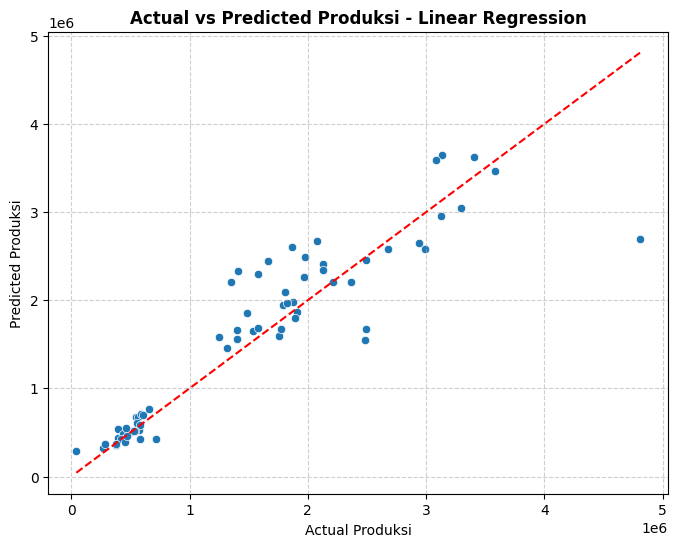

In [240]:
# Visualisasi Actual vs Predicted

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_actual.ravel(), y=y_test_pred.ravel())

min_val = min(y_test_actual.min(), y_test_pred.min())
max_val = max(y_test_actual.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red")

plt.title("Actual vs Predicted Produksi - Linear Regression", fontweight="bold")
plt.xlabel("Actual Produksi")
plt.ylabel("Predicted Produksi")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

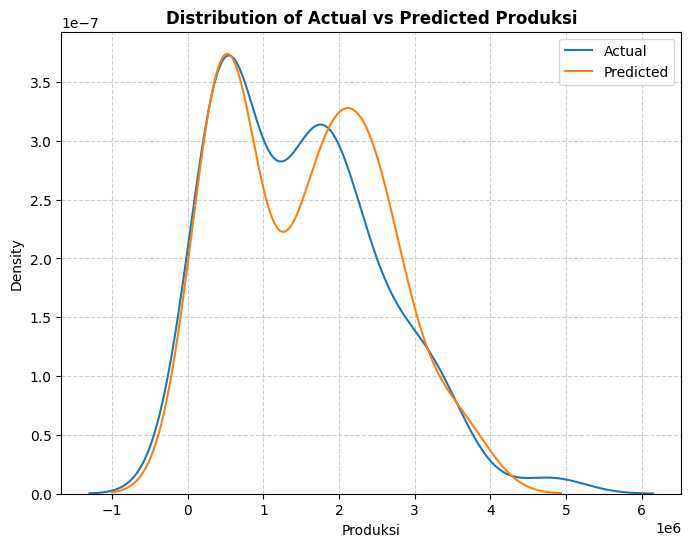

In [241]:
# Visualisasi Distribusi

plt.figure(figsize=(8, 6))
sns.kdeplot(y_test_actual.ravel(), label="Actual", fill=False)
sns.kdeplot(y_test_pred.ravel(), label="Predicted", fill=False)

plt.title("Distribution of Actual vs Predicted Produksi", fontweight="bold")
plt.xlabel("Produksi")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

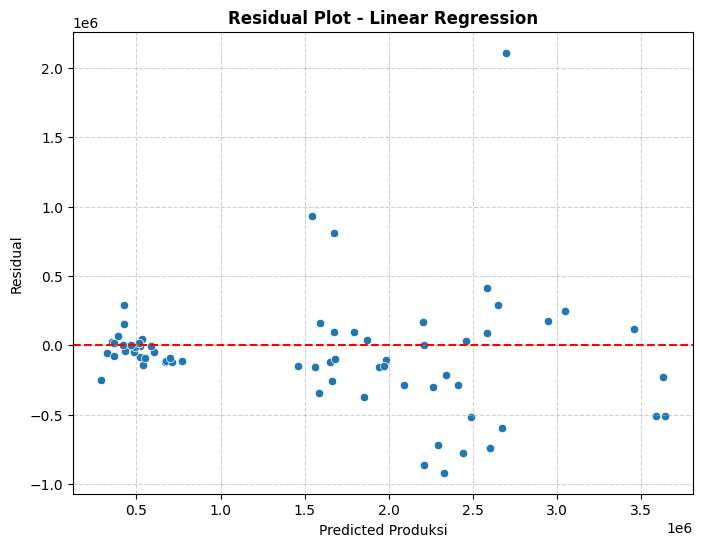

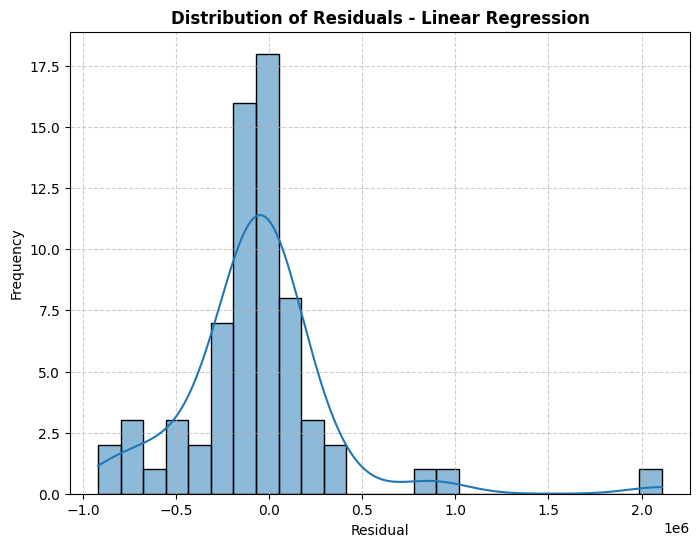

In [242]:
# Residual Analysis
residuals = y_test_actual.ravel() - y_test_pred.ravel()

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_pred.ravel(), y=residuals)
plt.axhline(y=0, color="red", linestyle="--")

plt.title("Residual Plot - Linear Regression", fontweight="bold")
plt.xlabel("Predicted Produksi")
plt.ylabel("Residual")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Distribusi residual
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals - Linear Regression", fontweight="bold")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

,Feature,Coefficient,Abs Coefficient
11,Provinsi_Sumatera Utara,0.804582,0.804582
5,Provinsi_Bengkulu,-0.615043,0.615043
8,Provinsi_Riau,-0.598688,0.598688
6,Provinsi_Jambi,-0.492515,0.492515
0,Luas Panen,0.447308,0.447308
7,Provinsi_Lampung,0.411065,0.411065
10,Provinsi_Sumatera Selatan,0.369555,0.369555
9,Provinsi_Sumatera Barat,0.077551,0.077551
1,Curah hujan,0.057658,0.057658
4,Provinsi_Aceh,0.043492,0.043492


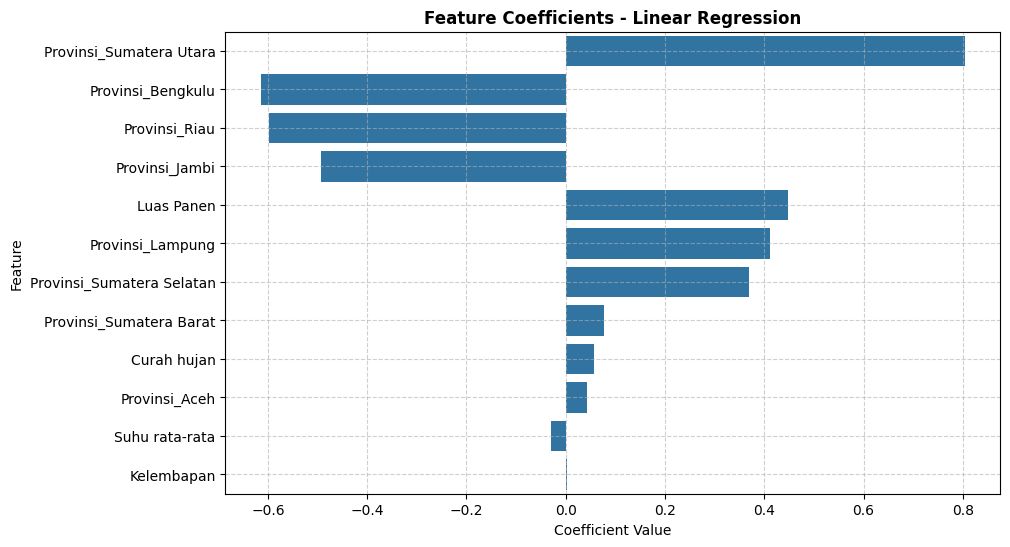

In [243]:
# Koefisien Linear Regression

coef_df = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Coefficient": linreg.coef_
})

coef_df["Abs Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Abs Coefficient", ascending=False)

display(coef_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x="Coefficient", y="Feature")

plt.title("Feature Coefficients - Linear Regression", fontweight="bold")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [244]:
# Hyperparameter Tuning

param_grid = {
    "fit_intercept": [True, False],
    "positive": [True, False]
}

linreg_tuning = LinearRegression()

grid_search = GridSearchCV(
    estimator=linreg_tuning,
    param_grid=param_grid,
    scoring="r2",
    cv=kfold,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train_scaled.values.ravel())

print("Best Parameters:", grid_search.best_params_)
print("Best CV R2 Score:", grid_search.best_score_)

Best Parameters: {'fit_intercept': True, 'positive': True}
Best CV R2 Score: 0.8276106225184661


In [245]:
# Fit linear model after fit parameter tuning

best_linreg = grid_search.best_estimator_

best_linreg.fit(X_train_scaled, y_train_scaled.values.ravel())

# Prediksi scaled
y_train_pred_best_scaled = best_linreg.predict(X_train_scaled)
y_test_pred_best_scaled = best_linreg.predict(X_test_scaled)

# Inverse transform
y_train_pred_best = y_scaler.inverse_transform(y_train_pred_best_scaled.reshape(-1, 1))
y_test_pred_best = y_scaler.inverse_transform(y_test_pred_best_scaled.reshape(-1, 1))

# Evaluasi final model
tuned_result = evaluate_regression_model(
    "Linear Regression Tuned",
    y_train_actual,
    y_train_pred_best,
    y_test_actual,
    y_test_pred_best
)

display(tuned_result)

,Model,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE,Train MAPE (%),Test MAPE (%)
0,Linear Regression Tuned,0.851638,0.835057,285716.482845,253727.944683,462340.064045,419045.335002,21.307222,24.390828


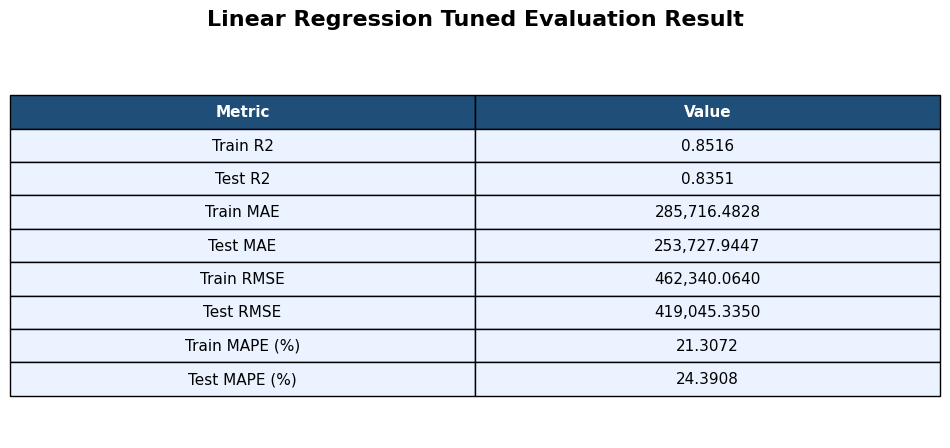

In [246]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# DATA HASIL EVALUASI
# =========================

evaluation_result = pd.DataFrame({

    "Metric": [

        "Train R2",
        "Test R2",

        "Train MAE",
        "Test MAE",

        "Train RMSE",
        "Test RMSE",

        "Train MAPE (%)",
        "Test MAPE (%)"
    ],

    "Value": [

        0.851638,
        0.835057,

        285716.482845,
        253727.944683,

        462340.064045,
        419045.335002,

        21.307222,
        24.390828
    ]
})

# Membulatkan angka
evaluation_result["Value"] = evaluation_result["Value"].apply(
    lambda x: f"{x:,.4f}"
)

# =========================
# MEMBUAT GAMBAR TABEL
# =========================

fig, ax = plt.subplots(figsize=(10, 5))

# Hilangkan axis
ax.axis('off')

# Judul
plt.title(
    "Linear Regression Tuned Evaluation Result",
    fontsize=16,
    fontweight='bold',
    pad=20
)

# Membuat tabel
table = ax.table(

    cellText=evaluation_result.values,

    colLabels=evaluation_result.columns,

    cellLoc='center',

    loc='center'
)

# =========================
# STYLING TABEL
# =========================

table.auto_set_font_size(False)

table.set_fontsize(11)

table.scale(1.2, 2)

# Styling warna
for (row, col), cell in table.get_celld().items():

    if row == 0:

        cell.set_text_props(weight='bold', color='white')

        cell.set_facecolor('#1F4E78')

    else:

        cell.set_facecolor('#EAF3FF')

# Simpan gambar
plt.savefig(
    "linear_regression_tuned_result.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [247]:
# Comarison

comparison_result = pd.concat([baseline_result, tuned_result], axis=0)
comparison_result = comparison_result.reset_index(drop=True)

display(comparison_result)

,Model,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE,Train MAPE (%),Test MAPE (%)
0,Linear Regression Baseline,0.852208,0.835823,285339.060589,252454.709367,461450.865758,418071.223654,21.715071,24.380484
1,Linear Regression Tuned,0.851638,0.835057,285716.482845,253727.944683,462340.064045,419045.335002,21.307222,24.390828


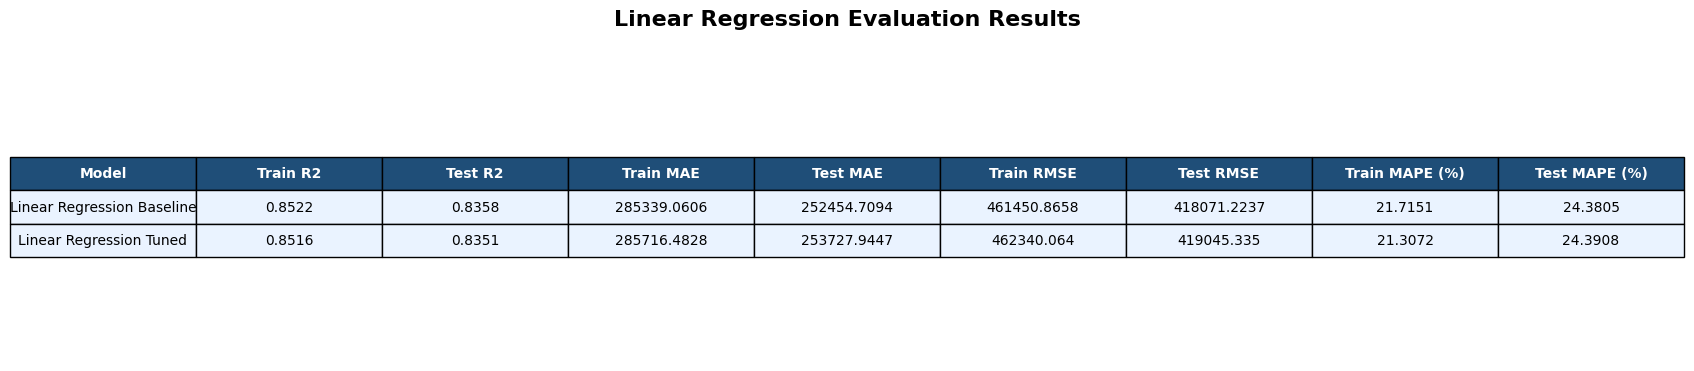

In [248]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# DATA HASIL EVALUASI
# =========================

evaluation_result = pd.DataFrame({

    "Model": [
        "Linear Regression Baseline",
        "Linear Regression Tuned"
    ],

    "Train R2": [
        0.852208,
        0.851638
    ],

    "Test R2": [
        0.835823,
        0.835057
    ],

    "Train MAE": [
        285339.060589,
        285716.482845
    ],

    "Test MAE": [
        252454.709367,
        253727.944683
    ],

    "Train RMSE": [
        461450.865758,
        462340.064045
    ],

    "Test RMSE": [
        418071.223654,
        419045.335002
    ],

    "Train MAPE (%)": [
        21.715071,
        21.307222
    ],

    "Test MAPE (%)": [
        24.380484,
        24.390828
    ]
})

# Membulatkan angka
evaluation_result = evaluation_result.round(4)

# =========================
# MEMBUAT GAMBAR TABEL
# =========================

fig, ax = plt.subplots(figsize=(18, 4))

# Hilangkan axis
ax.axis('off')

# Judul
plt.title(
    "Linear Regression Evaluation Results",
    fontsize=16,
    fontweight='bold',
    pad=20
)

# Membuat tabel
table = ax.table(

    cellText=evaluation_result.values,

    colLabels=evaluation_result.columns,

    cellLoc='center',

    loc='center'
)

# =========================
# STYLING
# =========================

table.auto_set_font_size(False)

table.set_fontsize(10)

table.scale(1.2, 2)

# Styling warna
for (row, col), cell in table.get_celld().items():

    if row == 0:

        cell.set_text_props(weight='bold', color='white')

        cell.set_facecolor('#1F4E78')

    else:

        cell.set_facecolor('#EAF3FF')

# Simpan gambar
plt.savefig(
    "linear_regression_evaluation_result.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

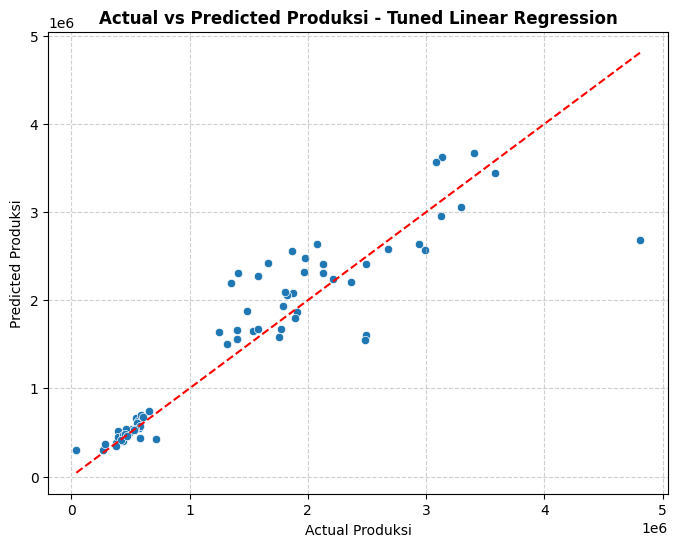

In [249]:
# Visualisasi

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_actual.ravel(), y=y_test_pred_best.ravel())

min_val = min(y_test_actual.min(), y_test_pred_best.min())
max_val = max(y_test_actual.max(), y_test_pred_best.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red")

plt.title("Actual vs Predicted Produksi - Tuned Linear Regression", fontweight="bold")
plt.xlabel("Actual Produksi")
plt.ylabel("Predicted Produksi")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [250]:
#
best_linreg_cv_scores = cross_val_score(
    best_linreg,
    X_train_scaled,
    y_train_scaled.values.ravel(),
    cv=kfold,
    scoring="r2"
)

print("Tuned Linear Regression")
print("CV R2 Scores:", best_linreg_cv_scores)
print("Average CV R2:", np.round(best_linreg_cv_scores.mean(), 4))
print("Std CV R2:", np.round(best_linreg_cv_scores.std(), 4))

Tuned Linear Regression
CV R2 Scores: [0.69034123 0.80024757 0.81155033 0.77473294 0.94569296 0.91097976
 0.94536312 0.79590827 0.90934341 0.69194663]
Average CV R2: 0.8276
Std CV R2: 0.0914


In [251]:
#

cv_comparison = pd.DataFrame({
    "Model": ["Linear Regression Baseline", "Linear Regression Tuned"],
    "Average CV R2": [
        cv_r2_scores.mean(),
        best_linreg_cv_scores.mean()
    ],
    "Std CV R2": [
        cv_r2_scores.std(),
        best_linreg_cv_scores.std()
    ]
})

display(cv_comparison)

,Model,Average CV R2,Std CV R2
0,Linear Regression Baseline,0.826719,0.090534
1,Linear Regression Tuned,0.827611,0.091376


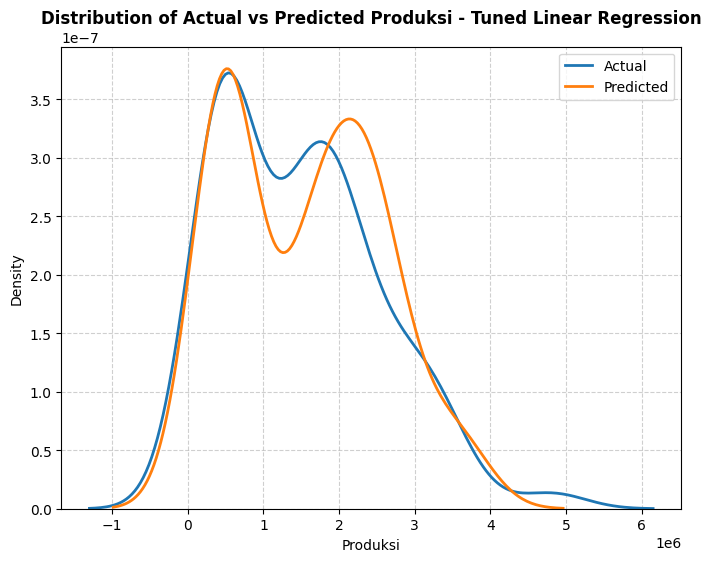

In [252]:
# visualisasi

plt.figure(figsize=(8, 6))

sns.kdeplot(
    y_test_actual.ravel(),
    label="Actual",
    fill=False,
    linewidth=2
)

sns.kdeplot(
    y_test_pred_best.ravel(),
    label="Predicted",
    fill=False,
    linewidth=2
)

plt.title("Distribution of Actual vs Predicted Produksi - Tuned Linear Regression", fontweight="bold")
plt.xlabel("Produksi")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

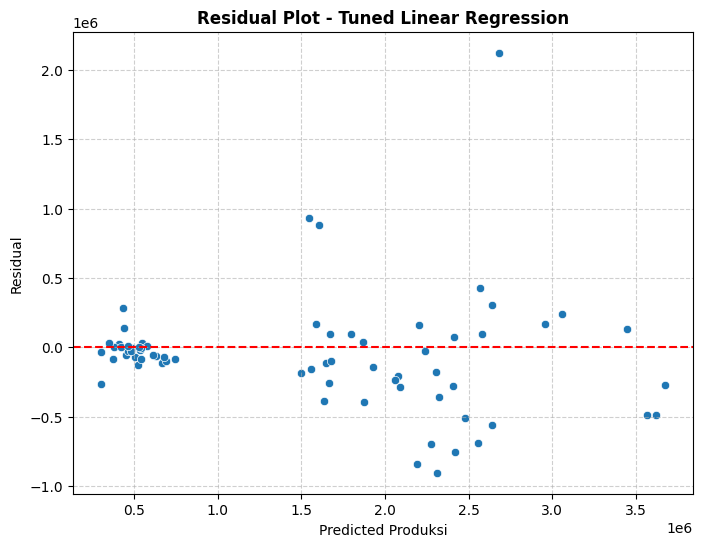

In [253]:
# ============================================================
# RESIDUAL PLOT AFTER TUNING
# ============================================================

residuals_best = y_test_actual.ravel() - y_test_pred_best.ravel()

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test_pred_best.ravel(),
    y=residuals_best
)

plt.axhline(y=0, color="red", linestyle="--")

plt.title("Residual Plot - Tuned Linear Regression", fontweight="bold")
plt.xlabel("Predicted Produksi")
plt.ylabel("Residual")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

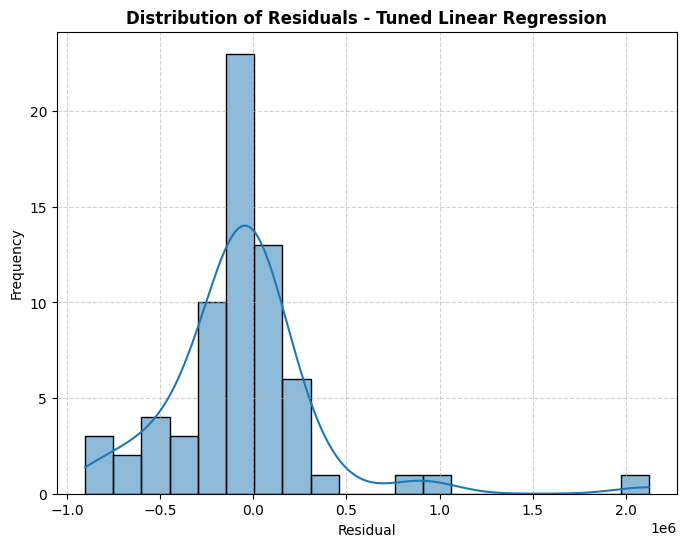

In [254]:
# Residual

plt.figure(figsize=(8, 6))

sns.histplot(
    residuals_best,
    kde=True,
    bins=20
)

plt.title("Distribution of Residuals - Tuned Linear Regression", fontweight="bold")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [255]:
# Residual

residual_table = pd.DataFrame({
    "Actual Produksi": y_test_actual.ravel(),
    "Predicted Produksi": y_test_pred_best.ravel(),
    "Residual": residuals_best,
    "Absolute Error": np.abs(residuals_best)
})

display(residual_table.head(10))
display(residual_table.tail(10))

,Actual Produksi,Predicted Produksi,Residual,Absolute Error
0,1314165.00,1.499973e+06,-185807.657298,185807.657298
1,436297.00,5.061761e+05,-69879.054260,69879.054260
2,550277.00,6.647501e+05,-114473.068020,114473.068020
3,1577398.00,2.274316e+06,-696917.678968,696917.678968
4,2488641.91,2.411886e+06,76755.428538,76755.428538
5,564722.00,6.290108e+05,-64288.756099,64288.756099
6,1907390.00,1.867024e+06,40366.243185,40366.243185
7,434144.00,4.066294e+05,27514.553988,27514.553988
8,379818.00,3.785145e+05,1303.512593,1303.512593
9,516869.00,5.333633e+05,-16494.275195,16494.275195


,Actual Produksi,Predicted Produksi,Residual,Absolute Error
58,288810.52,3.712529e+05,-82442.421418,82442.421418
59,1246614.00,1.636416e+06,-389802.238095,389802.238095
60,3079960.00,3.565555e+06,-485594.920234,485594.920234
61,1582393.00,1.677539e+06,-95146.462944,95146.462944
62,378377.00,3.497933e+05,28583.668076,28583.668076
63,2940795.00,2.639328e+06,301466.891571,301466.891571
64,657650.00,7.415310e+05,-83880.987393,83880.987393
65,2129914.00,2.308299e+06,-178385.315960,178385.315960
66,1404580.00,1.664957e+06,-260377.096975,260377.096975
67,1806424.00,2.090576e+06,-284152.442258,284152.442258


In [256]:
# ============================================================
# FINAL SUMMARY AFTER TUNING
# ============================================================

final_summary = pd.DataFrame({
    "Model": ["Tuned Linear Regression"],
    "Train R2": [r2_score(y_train_actual, y_train_pred_best)],
    "Test R2": [r2_score(y_test_actual, y_test_pred_best)],
    "Test MAE": [mean_absolute_error(y_test_actual, y_test_pred_best)],
    "Test RMSE": [np.sqrt(mean_squared_error(y_test_actual, y_test_pred_best))],
    "Test MAPE (%)": [mean_absolute_percentage_error(y_test_actual, y_test_pred_best) * 100],
    "Average CV R2": [best_linreg_cv_scores.mean()],
    "Std CV R2": [best_linreg_cv_scores.std()]
})

display(final_summary)

,Model,Train R2,Test R2,Test MAE,Test RMSE,Test MAPE (%),Average CV R2,Std CV R2
0,Tuned Linear Regression,0.851638,0.835057,253727.944683,419045.335002,24.390828,0.827611,0.091376


,Metric,Before Tuning,After Tuning
0,Train R2,0.8522,0.8516
1,Test R2,0.8358,0.8351
2,Train MAE,"285,339.0606","285,716.4828"
3,Test MAE,"252,454.7094","253,727.9447"
4,Train MSE,"212,936,901,508.6086","213,758,334,821.1646"
5,Test MSE,"174,783,548,047.9382","175,598,992,787.1909"
6,Train RMSE,"461,450.8658","462,340.0640"
7,Test RMSE,"418,071.2237","419,045.3350"
8,Train MAPE (%),21.7151,21.3072
9,Test MAPE (%),24.3805,24.3908


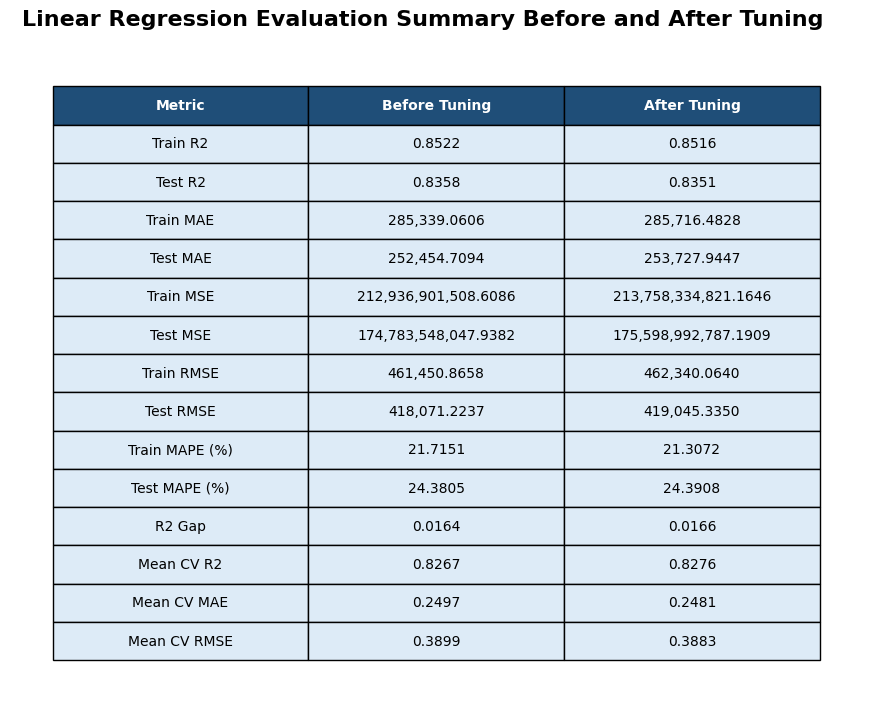

In [257]:
# ============================================================
# LINEAR REGRESSION EVALUATION SUMMARY
# BEFORE AND AFTER TUNING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

# ============================================================
# 1. HITUNG TAMBAHAN METRIK MSE
# ============================================================

# Before tuning / baseline
train_mse_before = mean_squared_error(y_train_actual, y_train_pred)
test_mse_before = mean_squared_error(y_test_actual, y_test_pred)

# After tuning
train_mse_after = mean_squared_error(y_train_actual, y_train_pred_best)
test_mse_after = mean_squared_error(y_test_actual, y_test_pred_best)

# ============================================================
# 2. HITUNG R2 GAP
# ============================================================

r2_gap_before = abs(
    baseline_result.loc[0, "Train R2"] - baseline_result.loc[0, "Test R2"]
)

r2_gap_after = abs(
    tuned_result.loc[0, "Train R2"] - tuned_result.loc[0, "Test R2"]
)

# ============================================================
# 3. CROSS VALIDATION UNTUK MAE DAN RMSE
#    Menggunakan data target yang sudah discaling,
#    agar nilainya sebanding seperti CV R2 di notebook.
# ============================================================

# Before tuning
cv_mae_before = -cross_val_score(
    linreg,
    X_train_scaled,
    y_train_scaled.values.ravel(),
    cv=kfold,
    scoring="neg_mean_absolute_error"
)

cv_rmse_before = -cross_val_score(
    linreg,
    X_train_scaled,
    y_train_scaled.values.ravel(),
    cv=kfold,
    scoring="neg_root_mean_squared_error"
)

# After tuning
cv_mae_after = -cross_val_score(
    best_linreg,
    X_train_scaled,
    y_train_scaled.values.ravel(),
    cv=kfold,
    scoring="neg_mean_absolute_error"
)

cv_rmse_after = -cross_val_score(
    best_linreg,
    X_train_scaled,
    y_train_scaled.values.ravel(),
    cv=kfold,
    scoring="neg_root_mean_squared_error"
)

# ============================================================
# 4. BUAT DATAFRAME SUMMARY
# ============================================================

summary_table = pd.DataFrame({
    "Metric": [
        "Train R2",
        "Test R2",
        "Train MAE",
        "Test MAE",
        "Train MSE",
        "Test MSE",
        "Train RMSE",
        "Test RMSE",
        "Train MAPE (%)",
        "Test MAPE (%)",
        "R2 Gap",
        "Mean CV R2",
        "Mean CV MAE",
        "Mean CV RMSE"
    ],
    "Before Tuning": [
        baseline_result.loc[0, "Train R2"],
        baseline_result.loc[0, "Test R2"],
        baseline_result.loc[0, "Train MAE"],
        baseline_result.loc[0, "Test MAE"],
        train_mse_before,
        test_mse_before,
        baseline_result.loc[0, "Train RMSE"],
        baseline_result.loc[0, "Test RMSE"],
        baseline_result.loc[0, "Train MAPE (%)"],
        baseline_result.loc[0, "Test MAPE (%)"],
        r2_gap_before,
        cv_r2_scores.mean(),
        cv_mae_before.mean(),
        cv_rmse_before.mean()
    ],
    "After Tuning": [
        tuned_result.loc[0, "Train R2"],
        tuned_result.loc[0, "Test R2"],
        tuned_result.loc[0, "Train MAE"],
        tuned_result.loc[0, "Test MAE"],
        train_mse_after,
        test_mse_after,
        tuned_result.loc[0, "Train RMSE"],
        tuned_result.loc[0, "Test RMSE"],
        tuned_result.loc[0, "Train MAPE (%)"],
        tuned_result.loc[0, "Test MAPE (%)"],
        r2_gap_after,
        best_linreg_cv_scores.mean(),
        cv_mae_after.mean(),
        cv_rmse_after.mean()
    ]
})

# ============================================================
# 5. FORMAT ANGKA AGAR RAPI
# ============================================================

summary_table_display = summary_table.copy()

for col in ["Before Tuning", "After Tuning"]:
    summary_table_display[col] = summary_table_display[col].apply(
        lambda x: f"{x:,.4f}"
    )

display(summary_table_display)

# ============================================================
# 6. VISUALISASI TABEL SEPERTI GAMBAR
# ============================================================

fig, ax = plt.subplots(figsize=(11, 7.5))
ax.axis("off")

# Judul menggunakan fig.suptitle agar posisinya lebih mudah dikontrol
fig.suptitle(
    "Linear Regression Evaluation Summary Before and After Tuning",
    fontsize=16,
    fontweight="bold",
    y=0.96
)

# Buat tabel, posisinya dinaikkan dengan bbox
table = ax.table(
    cellText=summary_table_display.values,
    colLabels=summary_table_display.columns,
    cellLoc="center",
    colLoc="center",
    bbox=[0.05, 0.05, 0.90, 0.90]
    # format bbox = [x, y, width, height]
    # y dan height ini yang mengatur jarak tabel ke judul
)

# Styling tabel
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

header_color = "#1F4E78"
body_color = "#DDEBF7"

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(1)

    if row == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor(body_color)

# Supaya layout tidak memberi ruang kosong berlebihan
plt.subplots_adjust(top=0.90, bottom=0.05)

plt.savefig(
    "linear_regression_summary_before_after_tuning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## **Random Forest Regression**

Mentukan fitur dan target

In [258]:
#Menentukan fitur dan target
# Target
y = df['Produksi']

# Fitur
X = df.drop(columns=['Produksi'])

Split Data

In [259]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Membuat model random forest

Membuat model Random Forest Regresssion

In [260]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

n_estimators 100 artinya menggunakan 100 decision tree.

Training model

In [261]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [262]:
# Prediksi data training
y_train_pred = model.predict(X_train)

# Prediksi data testing
y_pred = model.predict(X_test)

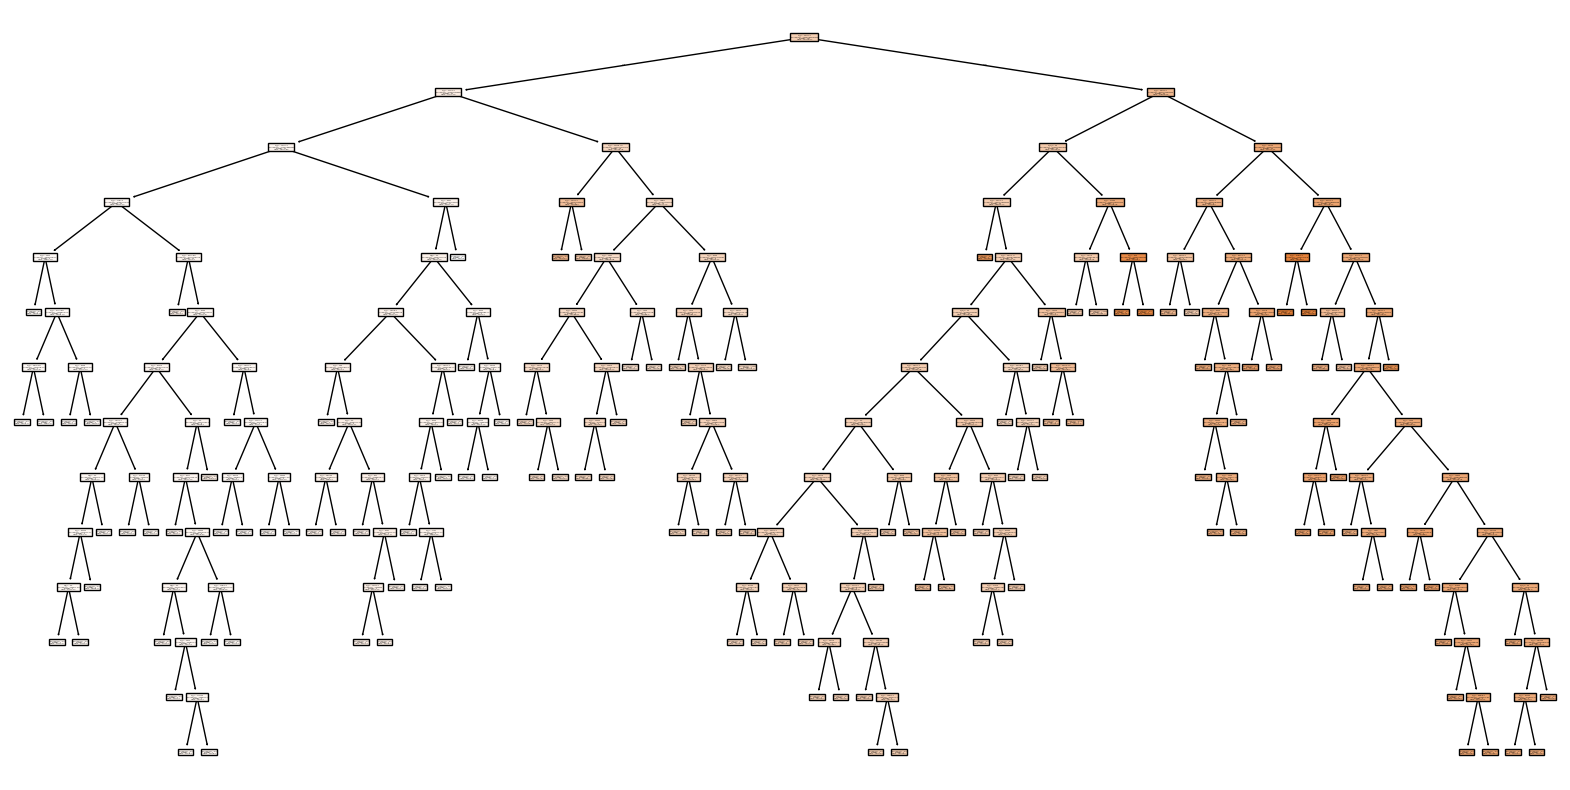

In [263]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    model.estimators_[0],
    filled=True
)

plt.show()

Evaluasi Model

In [264]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np
import pandas as pd


# Fungsi evaluasi model Random Forest Regression
def evaluate_regression_model(
    model_name,
    y_train_true,
    y_train_pred,
    y_test_true,
    y_test_pred
):

    # ======================
    # TRAINING METRICS
    # ======================

    train_r2 = r2_score(
        y_train_true,
        y_train_pred
    )

    train_mae = mean_absolute_error(
        y_train_true,
        y_train_pred
    )

    train_mse = mean_squared_error(
        y_train_true,
        y_train_pred
    )

    train_rmse = np.sqrt(train_mse)

    train_mape = mean_absolute_percentage_error(
        y_train_true,
        y_train_pred
    ) * 100


    # ======================
    # TESTING METRICS
    # ======================

    test_r2 = r2_score(
        y_test_true,
        y_test_pred
    )

    test_mae = mean_absolute_error(
        y_test_true,
        y_test_pred
    )

    test_mse = mean_squared_error(
        y_test_true,
        y_test_pred
    )

    test_rmse = np.sqrt(test_mse)

    test_mape = mean_absolute_percentage_error(
        y_test_true,
        y_test_pred
    ) * 100


    # ======================
    # OVERFITTING CHECK
    # ======================

    r2_gap = train_r2 - test_r2


    # ======================
    # HASIL EVALUASI
    # ======================

    result = pd.DataFrame({

        "Model": [model_name],

        # R2
        "Train R2": [train_r2],
        "Test R2": [test_r2],

        # MAE
        "Train MAE": [train_mae],
        "Test MAE": [test_mae],

        # MSE
        "Train MSE": [train_mse],
        "Test MSE": [test_mse],

        # RMSE
        "Train RMSE": [train_rmse],
        "Test RMSE": [test_rmse],

        # MAPE
        "Train MAPE (%)": [train_mape],
        "Test MAPE (%)": [test_mape],

        # Selisih R2
        "R2 Gap": [r2_gap]

    })

    return result


# ==========================================
# Evaluasi Random Forest Regression
# ==========================================

rf_result = evaluate_regression_model(

    "Random Forest Regression",

    y_train,
    y_train_pred,

    y_test,
    y_pred
)

display(rf_result)

,Model,Train R2,Test R2,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAPE (%),Test MAPE (%),R2 Gap
0,Random Forest Regression,0.971694,0.932819,110182.602989,174618.592936,4.093454e+10,5.939704e+10,202322.863904,243715.074836,7.541587,33.076261,0.038875


1. Hasil evaluasi model dengan data test menunjukkan nilai:
* MAE (Mean Absolute Error) = 130347.05
* MSE (Mean Squared Error) = 33552453723.82
* RMSE (Root Mean Squared Error) = 183173.29
*R^2 Score = 0.962
2. Nilai MAE sebesar 130347.05 menunjukkan bahwa rata-rata kesalahan prediksi model terhadap nilai aktual berada pada kisaran 130 ribu satuan produksi.
3. Nilai MSE sebesar 33552453723.82 menunjukkan adanya beberapa error prediksi yang cukup besar karena metode ini menghitung kuadrat dari setiap error sehingga lebih sensitif terhadap outlier.
4. Nilai RMSE sebesar 183173.29 menunjukkan bahwa rata-rata penyimpangan prediksi model terhadap data aktual masih tergolong baik terhadap skala data produksi padi yang digunakan.
5. Nilai R^2 Score sebesar 0.962 menunjukkan bahwa model mampu menjelaskan sekitar 96.2% variasi data produksi padi, sehingga performa model dapat dikategorikan sangat baik.

Berdasarkan hasil tersebut, metode Random Forest Regression mampu mempelajari pola hubungan antar fitur pada dataset dengan baik dan efektif digunakan untuk prediksi produksi tanaman padi.

In [265]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Cross Validation R2 Score
cv_r2 = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='r2'
)

# Cross Validation MAE
cv_mae = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='neg_mean_absolute_error'
)

# Cross Validation RMSE
cv_rmse = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

# =========================
# HASIL
# =========================

print("Cross Validation R2 Scores:")
print(cv_r2)

print("\nMean CV R2:")
print(np.mean(cv_r2))

print("\nCross Validation MAE:")
print(-cv_mae)

print("\nMean CV MAE:")
print(np.mean(-cv_mae))

print("\nCross Validation RMSE:")
print(-cv_rmse)

print("\nMean CV RMSE:")
print(np.mean(-cv_rmse))

Cross Validation R2 Scores:
[  0.59292273   0.38675132 -10.13678308   0.80404693   0.76129591]

Mean CV R2:
-1.5183532399056339

Cross Validation MAE:
[479048.53014    482553.38198889 208978.00982222 409541.62743556
 280208.76088182]

Mean CV MAE:
372066.0620536969

Cross Validation RMSE:
[539134.43327882 808148.98022498 481256.91790303 589951.85042313
 528732.8411006 ]

Mean CV RMSE:
589445.0045861144


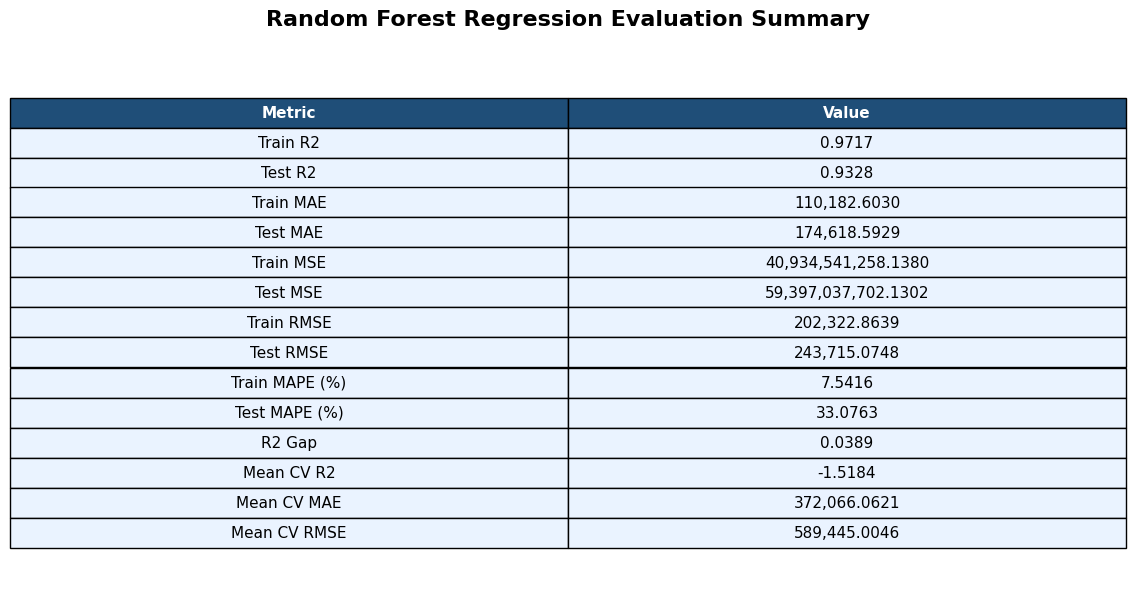

In [266]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================
# AMBIL DATA DARI rf_result
# =========================

summary_result = pd.DataFrame({

    "Metric": [

        "Train R2",
        "Test R2",

        "Train MAE",
        "Test MAE",

        "Train MSE",
        "Test MSE",

        "Train RMSE",
        "Test RMSE",

        "Train MAPE (%)",
        "Test MAPE (%)",

        "R2 Gap",

        "Mean CV R2",
        "Mean CV MAE",
        "Mean CV RMSE"
    ],

    "Value": [

        rf_result["Train R2"][0],
        rf_result["Test R2"][0],

        rf_result["Train MAE"][0],
        rf_result["Test MAE"][0],

        rf_result["Train MSE"][0],
        rf_result["Test MSE"][0],

        rf_result["Train RMSE"][0],
        rf_result["Test RMSE"][0],

        rf_result["Train MAPE (%)"][0],
        rf_result["Test MAPE (%)"][0],

        rf_result["R2 Gap"][0],

        np.mean(cv_r2),
        np.mean(-cv_mae),
        np.mean(-cv_rmse)
    ]
})

# Membulatkan angka
summary_result["Value"] = summary_result["Value"].apply(
    lambda x: f"{x:,.4f}"
)

# =========================
# MEMBUAT GAMBAR TABEL
# =========================

fig, ax = plt.subplots(figsize=(12, 7))

# Hilangkan axis
ax.axis('off')

# Judul
plt.title(
    "Random Forest Regression Evaluation Summary",
    fontsize=16,
    fontweight='bold',
    pad=20
)

# Membuat tabel
table = ax.table(

    cellText=summary_result.values,

    colLabels=summary_result.columns,

    cellLoc='center',

    loc='center'
)

# Styling tabel
table.auto_set_font_size(False)

table.set_fontsize(11)

table.scale(1.2, 1.8)

# Warna tabel
for (row, col), cell in table.get_celld().items():

    if row == 0:

        cell.set_text_props(weight='bold', color='white')

        cell.set_facecolor('#1F4E78')

    else:

        cell.set_facecolor('#EAF3FF')

# Simpan gambar
plt.savefig(
    "random_forest_evaluation_summary.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Prediksi

In [267]:
y_pred = model.predict(X_test)

print("Hasil Prediksi:")
print(y_pred[:10])

Hasil Prediksi:
[1485118.5336  227514.81    612257.75   1963149.5455 2271470.9768
  598450.6881 1904127.4876  395304.5408  411650.83    502895.67  ]


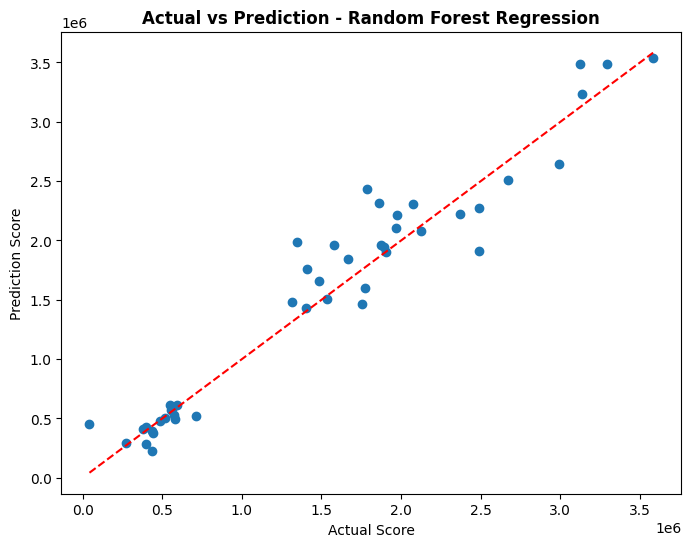

In [268]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(y_test, y_pred)

# Garis diagonal ideal
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Score")
plt.ylabel("Prediction Score")
plt.title("Actual vs Prediction - Random Forest Regression", fontweight = 'bold')

plt.show()

Distribuasi Actual vs Predicted

/tmp/ipykernel_2435/3034259117.py:8: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_test.ravel(),


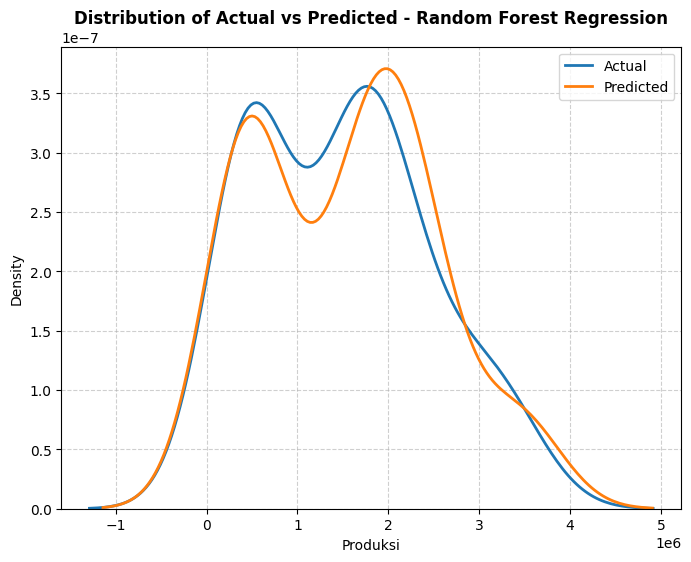

In [269]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# Distribusi nilai aktual
sns.kdeplot(
    y_test.ravel(),
    label="Actual",
    fill=False,
    linewidth=2
)

# Distribusi nilai prediksi
sns.kdeplot(
    y_pred.ravel(),
    label="Predicted",
    fill=False,
    linewidth=2
)

plt.title(
    "Distribution of Actual vs Predicted - Random Forest Regression",
    fontweight="bold"
)

plt.xlabel("Produksi")
plt.ylabel("Density")

plt.legend()

plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

Grafik Error

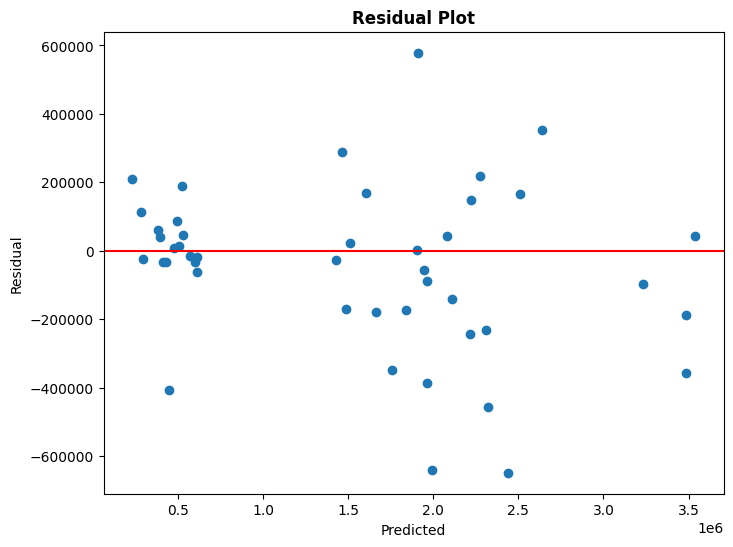

In [270]:
residual = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residual)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot", fontweight = 'bold')

plt.show()

Histogram Residual

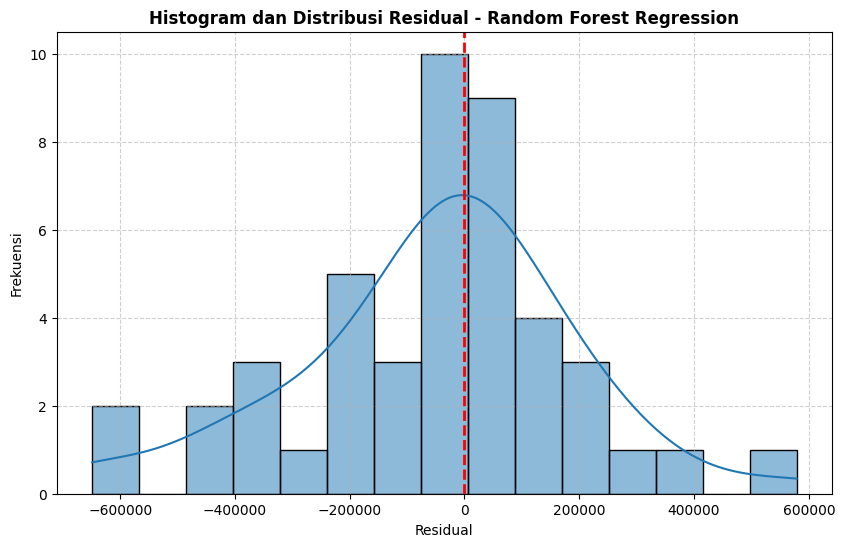

In [271]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menghitung residual
residual = y_test - y_pred

# Membuat figure
plt.figure(figsize=(10, 6))

# Histogram residual
sns.histplot(
    residual,
    bins=15,
    kde=True
)

# Garis vertikal di residual = 0
plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=2
)

# Judul dan label
plt.title(
    "Histogram dan Distribusi Residual - Random Forest Regression",
    fontweight="bold"
)

plt.xlabel("Residual")
plt.ylabel("Frekuensi")

# Grid
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

Feature Importance

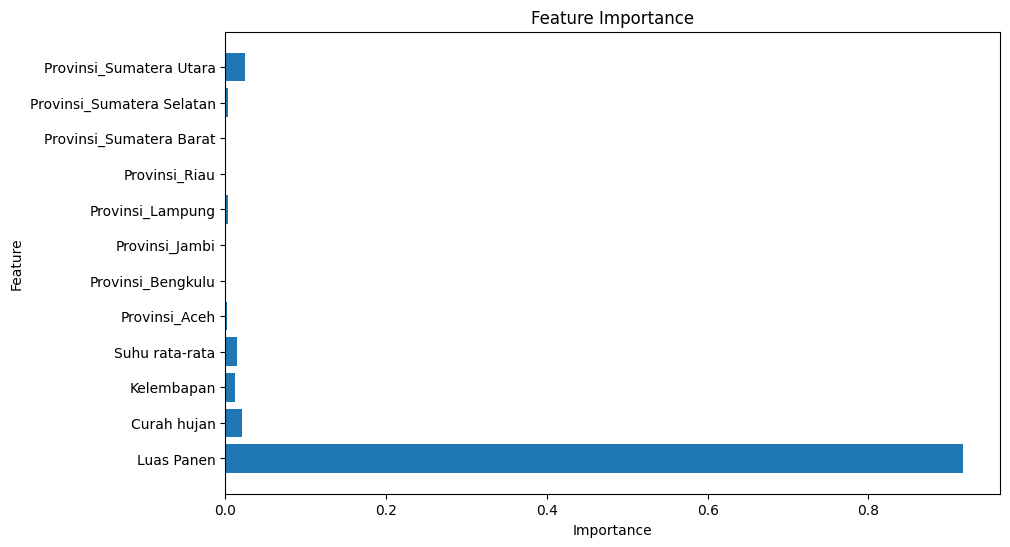

In [272]:
importance = model.feature_importances_

plt.figure(figsize=(10,6))

plt.barh(X.columns, importance)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

plt.show()